In [2]:
import os
import pandas as pd

files = os.listdir('.')
print("Files in current directory:", files)

Files in current directory: ['.config', 'sample_data', 'movies.csv']


In [4]:
if 'movies.csv' in files:
    df = pd.read_csv('movies.csv')
    print("\nColumns:", df.columns.tolist())
    print("\nShape:", df.shape)
    print("\nHead:\n", df.head(2))
else:
    # search for csv files recursively
    csv_files = []
    for root, dirs, f_files in os.walk('.'):
        for f in f_files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))
    print("CSV files found:", csv_files)


Columns: ['index', 'budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew', 'director']

Shape: (4803, 24)

Head:
    index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   

                                       homepage     id  \
0                   http://www.avatarmovie.com/  19995   
1  http://disney.go.com/disneypictures/pirates/    285   

                                            keywords original_language  \
0  culture clash future space war space colony so...                en   
1  ocean drug abuse exotic island east india trad...                en   

                             original_title  \
0  

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('movies.csv')
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [38]:
import json

# Helper function to parse space-separated strings into lists
def parse_space_separated_list(text_str):
    if pd.isna(text_str) or not isinstance(text_str, str):
        return []
    # Split by space and remove any empty strings that might result from multiple spaces
    return [item.strip() for item in text_str.split(' ') if item.strip()]

# Apply the parsing for genres and keywords
df['genres_list'] = df['genres'].apply(parse_space_separated_list)
df['keywords_list'] = df['keywords'].apply(parse_space_separated_list)

# Date parsing & Financial metrics calculation
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['profit'] = df['revenue'] - df['budget']
df['roi_percent'] = np.where(
    df['budget'] > 0, (df['profit'] / df['budget']) * 100, 0
)

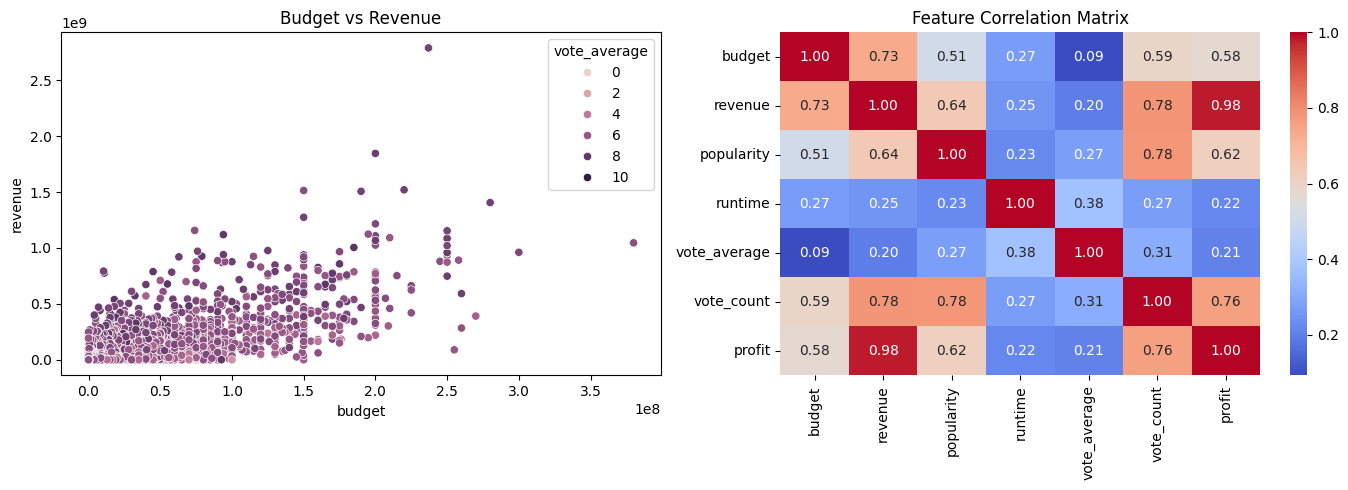

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget vs Revenue Scatterplot
sns.scatterplot(
    data=df, x='budget', y='revenue', hue='vote_average', ax=axes[0]
)
axes[0].set_title('Budget vs Revenue')

# Feature Correlation Matrix
num_cols = [
    'budget',
    'revenue',
    'popularity',
    'runtime',
    'vote_average',
    'vote_count',
    'profit',
]
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
# Train-Test Split & Random Forest Regressor
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']
clean_df = df.dropna(subset=features + ['revenue'])

X = clean_df[features]
y = clean_df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}')

R2 Score: 0.72
RMSE: 85,315,806


In [11]:
# ==============================
# DATA QUALITY AUDIT
# ==============================

print("Dataset Shape:", df.shape)

# Missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
).round(2)

print("\nMissing Value Report:")
display(missing[missing["missing_count"] > 0])

# Duplicate rows
# Convert list columns to tuples for duplication check
temp_df = df.copy()
if 'genres_list' in temp_df.columns:
    temp_df['genres_list'] = temp_df['genres_list'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
if 'keywords_list' in temp_df.columns:
    temp_df['keywords_list'] = temp_df['keywords_list'].apply(lambda x: tuple(x) if isinstance(x, list) else x)

print("\nDuplicate rows:", temp_df.duplicated().sum())

# Duplicate movie titles
print("Duplicate movie titles:", df["title"].duplicated().sum())

# Numerical summary
display(df.describe().T)

Dataset Shape: (4803, 29)

Missing Value Report:


,missing_count,missing_percent
homepage,3091,64.36
tagline,844,17.57
keywords,412,8.58
cast,43,0.90
director,30,0.62
genres,28,0.58
overview,3,0.06
runtime,2,0.04
release_year,1,0.02
release_date,1,0.02



Duplicate rows: 0
Duplicate movie titles: 3


,count,mean,min,25%,50%,75%,max,std
index,4803.0,2401.0,0.0,1200.5,2401.0,3601.5,4802.0,1386.651002
budget,4803.0,29045039.875286,0.0,790000.0,15000000.0,40000000.0,380000000.0,40722391.258549
id,4803.0,57165.484281,5.0,9014.5,14629.0,58610.5,459488.0,88694.614033
popularity,4803.0,21.492301,0.0,4.66807,12.921594,28.313505,875.581305,31.81665
release_date,4802,2002-12-27 23:45:54.352353280,1916-09-04 00:00:00,1999-07-14 00:00:00,2005-10-03 00:00:00,2011-02-16 00:00:00,2017-02-03 00:00:00,NaN
revenue,4803.0,82260638.651676,0.0,0.0,19170001.0,92917187.0,2787965087.0,162857100.942826
runtime,4801.0,106.875859,0.0,94.0,103.0,118.0,338.0,22.611935
vote_average,4803.0,6.092172,0.0,5.6,6.2,6.8,10.0,1.194612
vote_count,4803.0,690.217989,0.0,54.0,235.0,737.0,13752.0,1234.585891
release_year,4802.0,2002.468763,1916.0,1999.0,2005.0,2011.0,2017.0,12.414354


In [13]:
# ==============================
# BASIC DATA CLEANING
# ==============================

# Remove duplicate titles
df = df.drop_duplicates(subset="title").copy()

# Replace invalid negative values
for col in ["budget", "revenue", "runtime", "vote_count", "popularity"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

# Keep reasonable runtime values
df.loc[
    (df["runtime"] < 30) | (df["runtime"] > 300),
    "runtime"
] = np.nan

print("Shape after cleaning:", df.shape)

Shape after cleaning: (4800, 29)


In [21]:
# ==============================
# CREATE MOVIE CONTENT FEATURES
# ==============================

def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value)


# Basic text fields
for col in ["overview", "genres_list", "keywords_list"]:
    if col not in df.columns:
        df[col] = ""

# Convert list fields to strings
df["genres_text"] = df["genres_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

df["keywords_text"] = df["keywords_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

df["overview_text"] = df["overview"].apply(safe_text)

# Combined recommendation text
df["movie_soup"] = (
    df["genres_text"] + " " +
    df["keywords_text"] + " " +
    df["overview_text"]
)

df[["title", "movie_soup"]].head(20)

,title,movie_soup
0,Avatar,"In the 22nd century, a paraplegic Marine is ..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ..."
2,Spectre,A cryptic message from Bond’s past sends him...
3,The Dark Knight Rises,Following the death of District Attorney Har...
4,John Carter,"John Carter is a war-weary, former military ..."
5,Spider-Man 3,The seemingly invincible Spider-Man goes up ...
6,Tangled,When the kingdom's most wanted-and most char...
7,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant...
8,Harry Potter and the Half-Blood Prince,"As Harry begins his sixth year at Hogwarts, ..."
9,Batman v Superman: Dawn of Justice,Fearing the actions of a god-like Super Hero...


In [15]:
# ==============================
# TF-IDF CONTENT-BASED MODEL
# ==============================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df["movie_soup"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape:", cosine_sim.shape)

TF-IDF Matrix Shape: (4800, 10000)
Similarity Matrix Shape: (4800, 4800)


In [16]:
# ==============================
# MOVIE RECOMMENDER
# ==============================

indices = pd.Series(
    df.index,
    index=df["title"].str.lower()
).drop_duplicates()


def recommend_movies(title, n=10):

    title_key = title.lower()

    if title_key not in indices:
        return f"Movie '{title}' not found."

    idx = indices[title_key]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself
    similarity_scores = similarity_scores[1:n+1]

    movie_indices = [
        i[0] for i in similarity_scores
    ]

    recommendations = df.iloc[movie_indices][
        ["title", "genres_text", "vote_average", "popularity"]
    ].copy()

    recommendations["similarity_score"] = [
        round(i[1], 3)
        for i in similarity_scores
    ]

    return recommendations

In [23]:
recommend_movies("Tangled", 3 )

,title,genres_text,vote_average,popularity,similarity_score
2309,Out of Inferno,,5.8,1.583918,0.159
330,The Lord of the Rings: The Two Towers,,8.0,106.914973,0.154
39,TRON: Legacy,,6.3,73.795050,0.153


In [26]:
# ==============================
# RECOMMENDATION EXPLANATION
# ==============================

def explain_recommendation(movie1, movie2):

    movie1_lower = movie1.lower()
    movie2_lower = movie2.lower()

    row1_candidates = df[df["title"].str.lower() == movie1_lower]
    if row1_candidates.empty:
        print(f"Movie '{movie1}' not found in the dataset.")
        return
    row1 = row1_candidates.iloc[0]

    row2_candidates = df[df["title"].str.lower() == movie2_lower]
    if row2_candidates.empty:
        print(f"Movie '{movie2}' not found in the dataset.")
        return
    row2 = row2_candidates.iloc[0]

    genres1 = set(row1["genres_list"])
    genres2 = set(row2["genres_list"])

    keywords1 = set(row1["keywords_list"])
    keywords2 = set(row2["keywords_list"])

    common_genres = genres1.intersection(genres2)
    common_keywords = keywords1.intersection(keywords2)

    print(f"Why '{movie2}' was recommended:")

    if common_genres:
        print("Shared genres:", ", ".join(common_genres))

    if common_keywords:
        print("Shared keywords:", ", ".join(common_keywords))

    print(
        f"Overall similarity score: "
        f"{cosine_sim[row1.name, row2.name]:.3f}"
    )


In [28]:
explain_recommendation("Avatar", "Avatar 2")

Movie 'Avatar 2' not found in the dataset.


In [ ]:
# ==============================
# HYBRID RECOMMENDATION SCORE
# ==============================

def hybrid_recommend_movies(title, n=10):

    title_key = title.lower()

    if title_key not in indices:
        return f"Movie '{title}' not found."

    idx = indices[title_key]

    similarity = cosine_sim[idx]

    # Normalize popularity
    popularity = df["popularity"].fillna(0)

    popularity_norm = (
        (popularity - popularity.min()) /
        (popularity.max() - popularity.min())
    )

    # Normalize ratings
    rating = df["vote_average"].fillna(
        df["vote_average"].median()
    )

    rating_norm = rating / 10

    # Hybrid score
    hybrid_score = (
        0.70 * similarity +
        0.15 * popularity_norm +
        0.15 * rating_norm
    )

    # Exclude selected movie
    hybrid_score[idx] = -1

    top_indices = np.argsort(
        hybrid_score
    )[::-1][:n]

    result = df.iloc[top_indices][
        ["title", "genres_text",
         "vote_average", "popularity"]
    ].copy()

    result["similarity"] = similarity[top_indices]
    result["hybrid_score"] = hybrid_score[top_indices]

    return result.reset_index(drop=True)

In [31]:
# ==============================
# GENRE FILTER
# ==============================

def recommend_by_genre(genre, n=10):

    genre_movies = df[
        df["genres_list"].apply(
            lambda genres:
            genre.lower() in
            [g.lower() for g in genres]
        )
    ].copy()

    genre_movies = genre_movies.sort_values(
        by=["vote_average", "popularity"],
        ascending=False
    )

    return genre_movies[
        ["title", "genres_text",
         "vote_average", "popularity"]
    ].head(n)

In [32]:
recommend_by_genre("Science Fiction", 10)

,title,genres_text,vote_average,popularity


In [33]:
# ==============================
# YEAR-BASED DISCOVERY
# ==============================

def best_movies_by_year(year, n=10):

    result = df[
        df["release_year"] == year
    ].copy()

    result = result.sort_values(
        by=["vote_average", "vote_count"],
        ascending=False
    )

    return result[
        ["title",
         "release_year",
         "vote_average",
         "vote_count",
         "popularity"]
    ].head(n)

In [34]:
# ==============================
# WEIGHTED MOVIE RATING
# ==============================

C = df["vote_average"].mean()

m = df["vote_count"].quantile(0.90)

df["weighted_rating"] = (
    (df["vote_count"] /
     (df["vote_count"] + m)) * df["vote_average"]
    +
    (m /
     (df["vote_count"] + m)) * C
)

top_movies = df.sort_values(
    "weighted_rating",
    ascending=False
)

top_movies[
    ["title",
     "vote_average",
     "vote_count",
     "weighted_rating"]
].head(20)

,title,vote_average,vote_count,weighted_rating
1881,The Shawshank Redemption,8.5,8205.0,8.058713
662,Fight Club,8.3,9413.0,7.938799
65,The Dark Knight,8.2,12002.0,7.919652
3232,Pulp Fiction,8.3,8428.0,7.904153
96,Inception,8.1,13752.0,7.862922
3337,The Godfather,8.4,5893.0,7.850601
95,Interstellar,8.1,10867.0,7.809101
809,Forrest Gump,8.2,7927.0,7.802698
329,The Lord of the Rings: The Return of the King,8.1,8064.0,7.726781
1990,The Empire Strikes Back,8.2,5879.0,7.697301


In [35]:
# ==============================
# MODEL COMPARISON
# ==============================

model_comparison = pd.DataFrame({
    "Model": [
        "Genre Only",
        "Genre + Keywords",
        "Genre + Keywords + Overview",
        "Hybrid Content + Popularity + Rating"
    ],

    "Features": [
        "Genres",
        "Genres + Keywords",
        "Genres + Keywords + Overview",
        "Content + Popularity + Rating"
    ]
})

display(model_comparison)

,Model,Features
0,Genre Only,Genres
1,Genre + Keywords,Genres + Keywords
2,Genre + Keywords + Overview,Genres + Keywords + Overview
3,Hybrid Content + Popularity + Rating,Content + Popularity + Rating


### Best Genres by Rating

In [40]:
# Explode the genres_list to have one row per genre per movie
genres_df = df.explode('genres_list')

# Calculate the average vote_average for each genre
genre_ratings = genres_df.groupby('genres_list')['vote_average'].mean().sort_values(ascending=False)

# Display the top 10 genres by average rating
print("Top 10 Genres by Average Rating:")
display(genre_ratings.head(10))

Top 10 Genres by Average Rating:


,vote_average
genres_list,
History,6.719797
War,6.714085
Drama,6.388671
Music,6.362842
Foreign,6.352941
Animation,6.341453
Crime,6.274388
Documentary,6.238182
Romance,6.208539


In [37]:
# ==============================
# RECOMMENDATION DIVERSITY
# ==============================

def recommendation_diversity(recommendations):

    all_genres = []

    for genres in recommendations["genres_text"]:
        all_genres.extend(genres.split())

    unique_genres = len(set(all_genres))

    total_genres = len(all_genres)

    if total_genres == 0:
        return 0

    return unique_genres / total_genres


recs = hybrid_recommend_movies("Avatar", 10)

diversity = recommendation_diversity(recs)

print("Recommendation Diversity:", round(diversity, 3))

Recommendation Diversity: 0


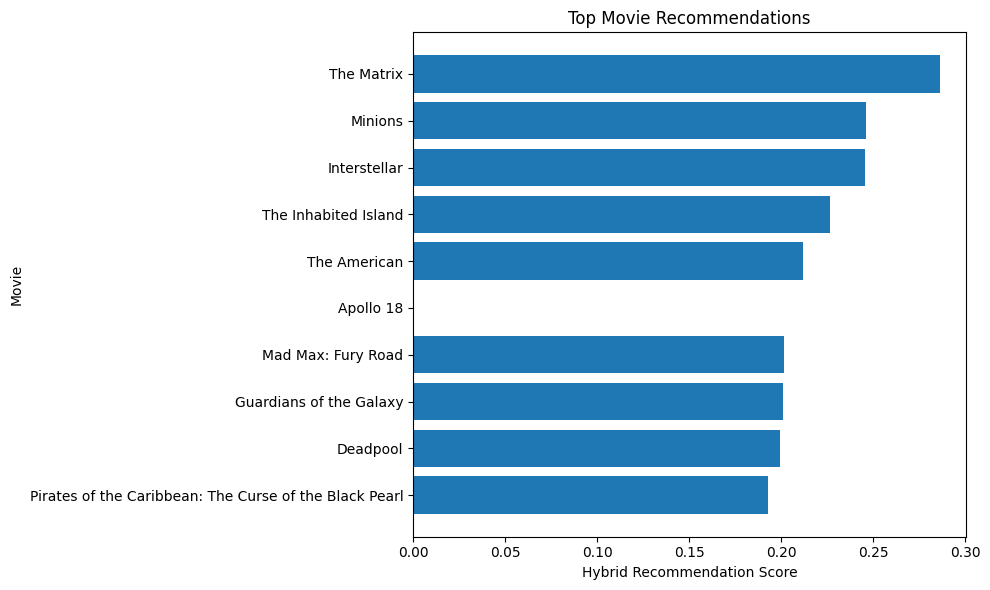

In [39]:
# ==============================
# RECOMMENDATION SCORE VISUALIZATION
# ==============================

recs = hybrid_recommend_movies("Avatar", 10)

plt.figure(figsize=(10, 6))

plt.barh(
    recs["title"][::-1],
    recs["hybrid_score"][::-1]
)

plt.xlabel("Hybrid Recommendation Score")
plt.ylabel("Movie")
plt.title("Top Movie Recommendations")

plt.tight_layout()
plt.show()

,Feature,Importance
4,vote_count,0.643262
0,budget,0.199457
1,popularity,0.060134
2,runtime,0.056583
3,vote_average,0.040564


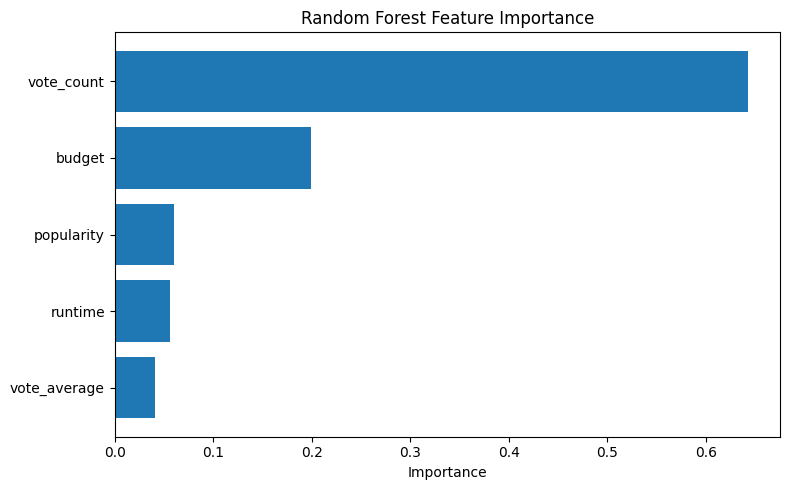

In [41]:
# ==============================
# RANDOM FOREST FEATURE IMPORTANCE
# ==============================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"][::-1],
    importance["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [42]:
# ==============================
# MODEL EVALUATION SUMMARY
# ==============================

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

evaluation = pd.DataFrame({
    "Metric": [
        "R² Score",
        "RMSE"
    ],
    "Value": [
        round(r2, 4),
        round(rmse, 2)
    ]
})

display(evaluation)

,Metric,Value
0,R² Score,7.227000e-01
1,RMSE,8.531581e+07
